# Лабораторна робота №3: відновлення зображень

Моделюємо спотворення **розмиттям рухом** (PSF) та **гаусівським шумом**, далі порівнюємо **інверсну фільтрацію** у частотній області, **вінерівське** відновлення (`skimage.restoration.wiener`) та **Richardson–Lucy** деконволюцію (`skimage.restoration.richardson_lucy`). Усі результати зберігаються у `results/`.


## 1. Імпорт бібліотек

Підключаємо роботу зі шляхами, масивами, OpenCV, візуалізацію, модуль `scipy.signal` та алгоритми відновлення з `skimage.restoration`.

**Очікуваний результат:** імпорт без помилок.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal
# Модуль scipy.signal з переліку ТЗ (згортки, спектральні методи); FFT тут — через numpy.fft.
from skimage import restoration

np.random.seed(42)


## 2. Налаштування шляхів

`NOTEBOOK_DIR` визначається від поточної робочої папки, щоб однаково працювало при запуску з `Lab_03` або з кореня репозиторію (наприклад, `jupyter nbconvert --execute`).

**Очікуваний результат:** `IMAGE_PATH` вказує на `satir.jpg` у корені, `RESULTS_DIR` — на `Lab_03/results/`.


In [2]:
_cwd = Path.cwd().resolve()
NOTEBOOK_DIR = _cwd if (_cwd / "Lab_03.ipynb").is_file() else (_cwd / "Lab_03")
ROOT = NOTEBOOK_DIR.parent.resolve()
IMAGE_PATH = ROOT / "satir.jpg"
RESULTS_DIR = (NOTEBOOK_DIR / "results").resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("ROOT:", ROOT)
print("IMAGE_PATH:", IMAGE_PATH)
print("RESULTS_DIR:", RESULTS_DIR)


NOTEBOOK_DIR: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_03
ROOT: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP
IMAGE_PATH: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\satir.jpg
RESULTS_DIR: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_03\results


## 3. Читання / запис зображень (Unicode, Windows)

`cv2.imread` може не відкрити файл з не-ASCII у шляху. Використовуємо `numpy.fromfile` + `cv2.imdecode` та симетрично `imencode` + `tofile` для збереження.

**Очікуваний результат:** зображення завантажується у `uint8` градаціях сірого.


In [3]:
def imread_gray_unicode(path: Path) -> np.ndarray:
    data = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Не вдалося прочитати: {path}")
    return img


def imwrite_unicode(path: Path, image: np.ndarray) -> None:
    ok, buf = cv2.imencode(path.suffix, image)
    if not ok:
        raise RuntimeError(f"Не вдалося закодувати: {path}")
    buf.tofile(str(path))


## 4. Завантаження оригіналу та збереження

**Відновлення vs покращення:** відновлення намагається **інвертувати відоме спотворення** (наприклад, згортку з PSF), тоді як «покращення» часто означає загальні евристики (контраст, різкість) без явної моделі спотворення.

**Очікуваний результат:** еталон `original_gray.png` для порівняння.


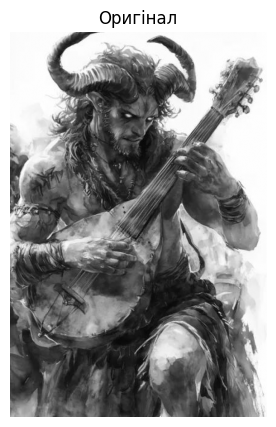

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_03\results\original_gray.png


In [4]:
img_original = imread_gray_unicode(IMAGE_PATH)

plt.figure(figsize=(5, 5))
plt.imshow(img_original, cmap="gray")
plt.title("Оригінал")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS_DIR / "original_gray.png", img_original)
print("Збережено:", RESULTS_DIR / "original_gray.png")


## 5. PSF розмиття рухом і застосування `filter2D`

**PSF (Point Spread Function)** — відгук системи на точкове джерело; у моделі згортки це ядро h.

Створюємо горизонтальну «лінію» у матриці та **повертаємо** її на заданий кут через `cv2.warpAffine`. Ядро нормалізуємо (сума = 1), щоб зберегти середню яскравість.

**Очікуваний результат:** `motion_blur.png` — контури менш чіткі.


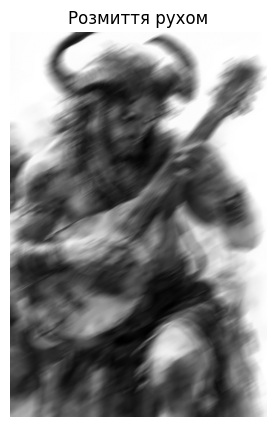

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_03\results\motion_blur.png


In [5]:
def motion_blur_kernel(size: int = 21, angle: float = 30) -> np.ndarray:
    k = np.zeros((size, size), dtype=np.float32)
    k[size // 2, :] = 1.0
    center = (size / 2.0 - 0.5, size / 2.0 - 0.5)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    k_rot = cv2.warpAffine(k, M, (size, size), flags=cv2.INTER_LINEAR)
    s = float(k_rot.sum())
    if s > 0:
        k_rot /= s
    return k_rot


psf = motion_blur_kernel(size=21, angle=30)
img_blur = cv2.filter2D(img_original, -1, psf, borderType=cv2.BORDER_REPLICATE)

plt.figure(figsize=(5, 5))
plt.imshow(img_blur, cmap="gray")
plt.title("Розмиття рухом")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS_DIR / "motion_blur.png", img_blur)
print("Збережено:", RESULTS_DIR / "motion_blur.png")


## 6. Гаусівський шум після розмиття

Модель ближча до реальності: g = h * f + n. Шум ускладнює **інверсне** відновлення, бо малих |H| у спектрі відповідає **сильне підсилення** високочастотних компонент шуму.

**Очікуваний результат:** `motion_blur_noise.png` — додаткова зернистість.


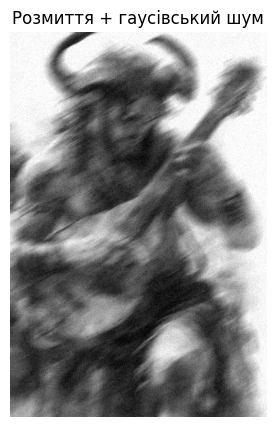

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_03\results\motion_blur_noise.png


In [6]:
def add_gaussian_noise(image: np.ndarray, mean: float = 0, sigma: float = 10) -> np.ndarray:
    noise = np.random.normal(mean, sigma, image.shape)
    out = image.astype(np.float64) + noise
    return np.clip(out, 0, 255).astype(np.uint8)


img_blur_noise = add_gaussian_noise(img_blur, mean=0, sigma=10)

plt.figure(figsize=(5, 5))
plt.imshow(img_blur_noise, cmap="gray")
plt.title("Розмиття + гаусівський шум")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS_DIR / "motion_blur_noise.png", img_blur_noise)
print("Збережено:", RESULTS_DIR / "motion_blur_noise.png")


## 7. Інверсна фільтрація у частотній області

Розширюємо PSF до розміру зображення, обчислюємо G = F(g), H = F(h). Інверсія: F_hat = G / H з **регуляризацією** `eps` там, де |H| дуже мале.

**Чому інверсія чутлива до шуму:** ділення на малі H підсилює високі частоти, де переважає спектр шуму.

**Очікуваний результат:** для зображення **без** додаткового шуму — часткове відновлення різкості з можливими крайовими артефактами (циклічна модель FFT).


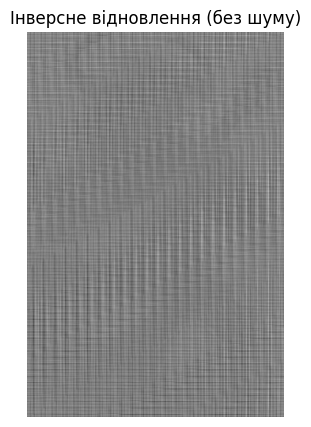

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_03\results\inverse_restored.png


In [7]:
def _pad_psf_for_fft(psf: np.ndarray, shape: tuple[int, int]) -> np.ndarray:
    H, W = shape
    out = np.zeros((H, W), dtype=np.float64)
    ph, pw = psf.shape
    i0 = (H - ph) // 2
    j0 = (W - pw) // 2
    out[i0 : i0 + ph, j0 : j0 + pw] = np.asarray(psf, dtype=np.float64)
    return np.fft.ifftshift(out)


def inverse_filter(blurred: np.ndarray, psf: np.ndarray, eps: float = 1e-3) -> np.ndarray:
    g = blurred.astype(np.float64)
    h_pad = _pad_psf_for_fft(psf, g.shape)
    G = np.fft.fft2(g)
    H = np.fft.fft2(h_pad)
    F_hat = np.zeros_like(G, dtype=np.complex128)
    mask = np.abs(H) > eps
    F_hat[mask] = G[mask] / H[mask]
    f_hat = np.real(np.fft.ifft2(F_hat))
    f_hat = f_hat - f_hat.min()
    mx = f_hat.max()
    if mx > 1e-12:
        f_hat = f_hat / mx * 255.0
    return np.clip(f_hat, 0, 255).astype(np.uint8)


img_inv_clean = inverse_filter(img_blur, psf, eps=1e-3)

plt.figure(figsize=(5, 5))
plt.imshow(img_inv_clean, cmap="gray")
plt.title("Інверсне відновлення (без шуму)")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS_DIR / "inverse_restored.png", img_inv_clean)
print("Збережено:", RESULTS_DIR / "inverse_restored.png")


## 8. Інверсна фільтрація за наявності шуму

Той самий `inverse_filter` на `motion_blur_noise.png`. Шум у спектрі перетворюється на великі просторові артефакти після «підсилення» інверсією.

**Очікуваний результат:** сильне погіршення якості, зерно, кільця — наочна демонстрація нестійкості.


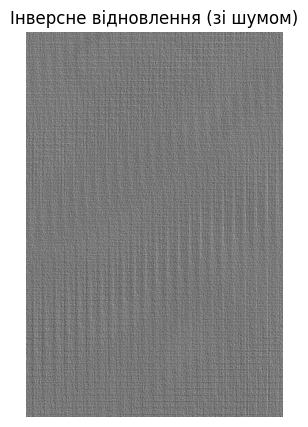

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_03\results\inverse_restored_noisy.png


In [8]:
img_inv_noisy = inverse_filter(img_blur_noise, psf, eps=1e-3)

plt.figure(figsize=(5, 5))
plt.imshow(img_inv_noisy, cmap="gray")
plt.title("Інверсне відновлення (зі шумом)")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS_DIR / "inverse_restored_noisy.png", img_inv_noisy)
print("Збережено:", RESULTS_DIR / "inverse_restored_noisy.png")


## 9. Вінерівське відновлення (`skimage.restoration.wiener`)

Вінер вводить **стабілізацію** відносно шуму через параметр `balance`. Зображення нормалізуємо до [0, 1], PSF — у `float` з одиничною сумою.

**Чому стабільніший за інверсію:** менше неконтрольованого підсилення на частотах, де SNR низький.

**Очікуваний результат:** зазвичай прийнятніший компроміс між різкістю та придушенням шуму.


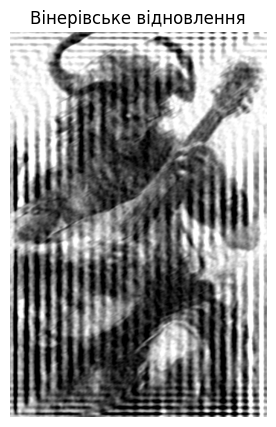

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_03\results\wiener_restored.png


In [9]:
psf_f = psf.astype(np.float64)
psf_f /= psf_f.sum() + 1e-12

img_nn = img_blur_noise.astype(np.float64) / 255.0
img_w = restoration.wiener(img_nn, psf_f, balance=0.05, clip=True)
img_w = np.clip(img_w * 255.0, 0, 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(img_w, cmap="gray")
plt.title("Вінерівське відновлення")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS_DIR / "wiener_restored.png", img_w)
print("Збережено:", RESULTS_DIR / "wiener_restored.png")


## 10. Richardson–Lucy деконволюція

Ітеративний метод; кількість ітерацій задаємо `num_iter=30` (або сумісний варіант через `try` / `except`).

**Очікуваний результат:** можливе підсилення різкості; при завеликій кількості ітерацій — кільця та шум.


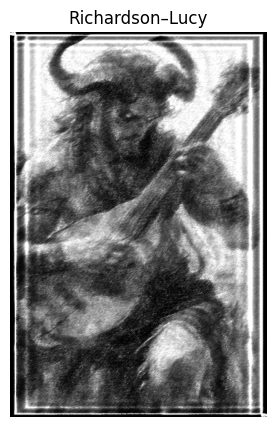

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_03\results\richardson_lucy_restored.png


In [10]:
try:
    img_rl = restoration.richardson_lucy(img_nn, psf_f, num_iter=30, clip=True)
except TypeError:
    img_rl = restoration.richardson_lucy(img_nn, psf_f, iterations=30, clip=True)

img_rl = np.clip(img_rl * 255.0, 0, 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(img_rl, cmap="gray")
plt.title("Richardson–Lucy")
plt.axis("off")
plt.show()

imwrite_unicode(RESULTS_DIR / "richardson_lucy_restored.png", img_rl)
print("Збережено:", RESULTS_DIR / "richardson_lucy_restored.png")


## 11. Порівняльна фігура (2×4)

Сім панелей + одна порожня: оригінал, розмиття, розмиття+шум, інверсія без шуму, інверсія зі шумом, Вінер, Richardson–Lucy.

`savefig` виконується **перед** `show()`.


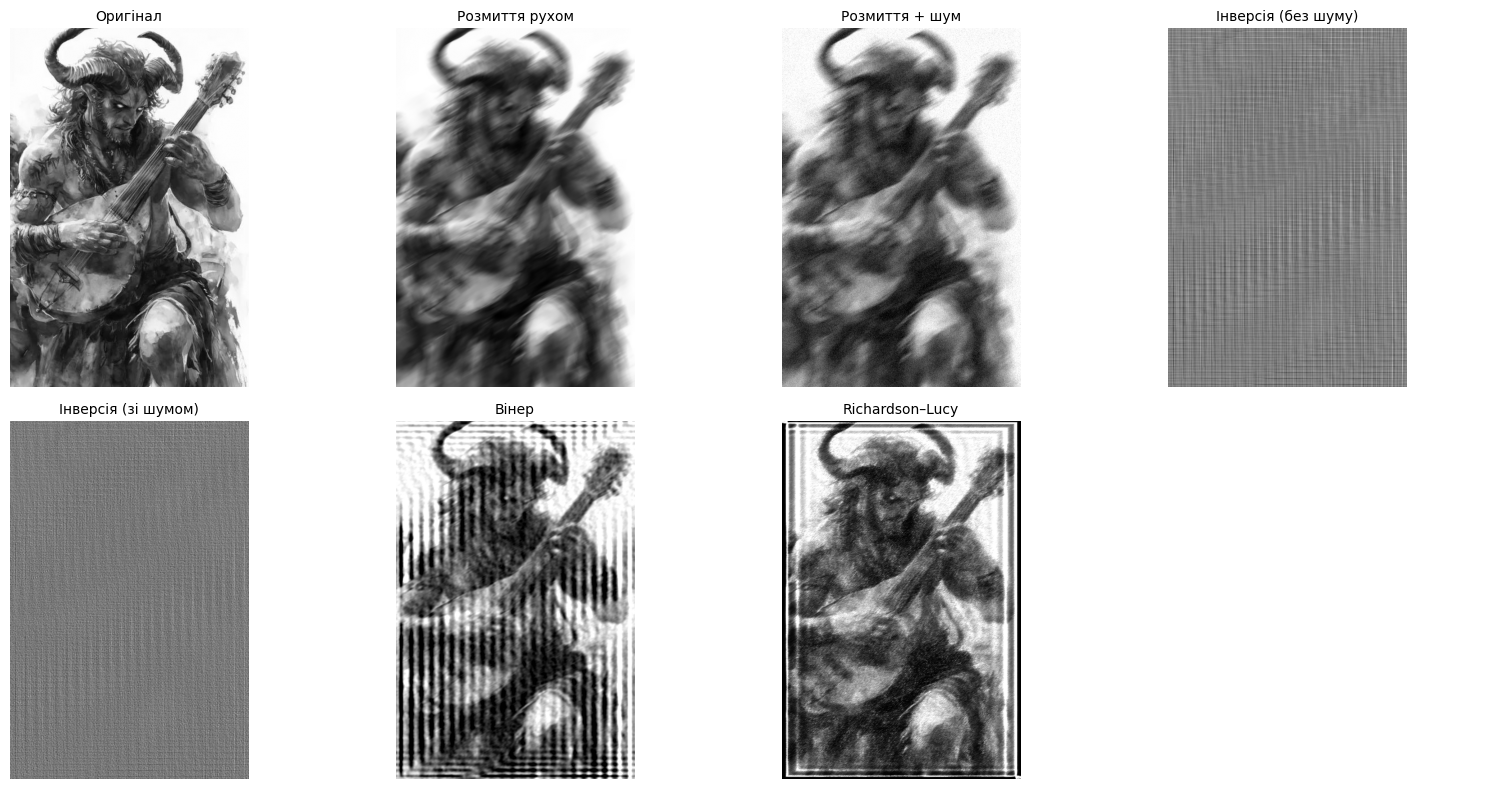

Збережено: C:\Users\feost\OneDrive\Документи\CNU Education\AISIP\Lab_03\results\comparison.png


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
panels = [
    (img_original, "Оригінал"),
    (img_blur, "Розмиття рухом"),
    (img_blur_noise, "Розмиття + шум"),
    (img_inv_clean, "Інверсія (без шуму)"),
    (img_inv_noisy, "Інверсія (зі шумом)"),
    (img_w, "Вінер"),
    (img_rl, "Richardson–Lucy"),
]
for ax, (im, title) in zip(axes.ravel(), panels):
    ax.imshow(im, cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
axes.ravel()[-1].axis("off")

fig.tight_layout()
fig.savefig(RESULTS_DIR / "comparison.png", dpi=110, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Збережено:", RESULTS_DIR / "comparison.png")


## 12. Перевірка створених файлів

Переконуємося, що всі файли для звіту існують у `results/`.


In [12]:
expected = [
    "original_gray.png",
    "motion_blur.png",
    "motion_blur_noise.png",
    "inverse_restored.png",
    "inverse_restored_noisy.png",
    "wiener_restored.png",
    "richardson_lucy_restored.png",
    "comparison.png",
]
missing = [name for name in expected if not (RESULTS_DIR / name).is_file()]
if missing:
    print("Відсутні файли:", missing)
else:
    print("Усі результати лабораторної роботи №3 успішно створено.")


Усі результати лабораторної роботи №3 успішно створено.
